In [1]:
# =====================================================
# =====================================================
import os
import random
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys  
import time
from torch.cuda.amp import autocast, GradScaler

from tqdm.notebook import tqdm  

import numpy as np
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

from scipy.ndimage import minimum_filter
from scipy.ndimage import label


# -----------------------------------------------------
# Device & Global Flags
# -----------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")
import torch
print(torch.__version__)
torch.backends.cudnn.benchmark = True


Device: cuda NVIDIA GeForce RTX 3060 Laptop GPU
2.4.1+cu121


In [2]:
def prepare_mnist_with_grey_dots_cpu(
    mat_path,
    class_ratio=0.5,
    split_ratios={'train': 0.7, 'val': 0.15, 'test': 0.15},
    seed=42,
    dot_params=None
):
    np.random.seed(seed)

    # --- Load data ---
    data = loadmat(mat_path)
    X = data['data'].T  # (n_samples, 784)
    y = data['label'].flatten()

    # --- Reduce dataset size by class ---
    X_subset, y_subset = [], []
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        n_select = int(len(idx) * class_ratio)
        selected_idx = np.random.choice(idx, n_select, replace=False)
        X_subset.append(X[selected_idx])
        y_subset.append(y[selected_idx])
    X = np.concatenate(X_subset)
    y = np.concatenate(y_subset)

    # --- Shuffle ---
    X, y = shuffle(X, y, random_state=seed)

    # --- Stratified split ---
    train_ratio = split_ratios['train']
    val_ratio = split_ratios['val'] / (split_ratios['val'] + split_ratios['test'])

    X_train, X_rest, y_train, y_rest = train_test_split(
        X, y, train_size=train_ratio, stratify=y, random_state=seed)
    X_val, X_test, y_val, y_test = train_test_split(
        X_rest, y_rest, train_size=val_ratio, stratify=y_rest, random_state=seed)

    # --- Add grey dots + record their positions ---
    def add_grey_dots_np(X_np):
        X_mod = X_np.copy().reshape(-1, 28, 28)
        N = X_mod.shape[0]
        dot_locations = []

        # Convert image to strict black-and-white
        X_strict = np.where(X_mod > 50, 255, 0).astype(np.uint8)
        bright_pixels = [np.argwhere(img == 255) for img in X_strict]

        for i in range(N):
            coords = bright_pixels[i]
            if coords.size == 0:
                dot_locations.append(None)
                continue

            # --- Location ---
            if dot_params and dot_params.get('location') is not None:
                y_dot, x_dot = dot_params['location']
            else:
                y_dot, x_dot = coords[np.random.randint(len(coords))]

            # --- Radius (size) ---
            if dot_params and dot_params.get('radius') is not None:
                radius = int(dot_params['radius'])
            else:
                radius = np.random.randint(1, 3)

            # --- Intensity ---
            if dot_params and dot_params.get('gray') is not None:
                gray = int(dot_params['gray'])
            else:
                gray = np.random.randint(100, 181)

            # --- Apply circular grey dot ---
            y_min = max(y_dot - radius, 0)
            y_max = min(y_dot + radius, 27)
            x_min = max(x_dot - radius, 0)
            x_max = min(x_dot + radius, 27)

            ys, xs = np.ogrid[y_min:y_max+1, x_min:x_max+1]
            dist_sq = (ys - y_dot)**2 + (xs - x_dot)**2
            mask = dist_sq <= radius**2

            X_mod[i, y_min:y_max+1, x_min:x_max+1][mask] = gray

            # Save location
            dot_locations.append({
                'y': int(y_dot),
                'x': int(x_dot),
                'radius': int(radius),
                'gray': int(gray)
            })

        return X_mod.reshape(-1, 784).astype(np.uint8), dot_locations
    # --- Save original images before modifying ---
    X_train_orig = X_train.copy()
    X_val_orig   = X_val.copy()
    X_test_orig  = X_test.copy()
    # Apply grey dot addition
    X_train, dots_train = add_grey_dots_np(X_train)
    X_val, dots_val = add_grey_dots_np(X_val)
    X_test, dots_test = add_grey_dots_np(X_test)

    # Return dictionary with original images added
    return {
        'train': {'X': X_train, 'X_orig': X_train_orig, 'y': y_train, 'dots': dots_train},
        'val':   {'X': X_val,   'X_orig': X_val_orig,   'y': y_val,   'dots': dots_val},
        'test':  {'X': X_test,  'X_orig': X_test_orig,  'y': y_test,  'dots': dots_test}
    }


In [3]:
class InMemoryMNISTDataset(Dataset):
    def __init__(self, X, y, dots=None, X_orig=None, transform=None,
                 return_dot_info=False, return_index=False, return_orig=False):
        self.X = X
        self.y = y
        self.dots = dots
        self.X_orig = X_orig
        self.transform = transform
        self.return_dot_info = return_dot_info
        self.return_index = return_index
        self.return_orig = return_orig

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        label = self.y[idx]

        # --- Original image ---
        image_orig = self.X_orig[idx] if self.X_orig is not None else None

        # --- Ensure shape ---
        if image.ndim == 1:
            image = image.reshape(28, 28)
        if image_orig is not None and image_orig.ndim == 1:
            image_orig = image_orig.reshape(28, 28)

        # --- Convert to PIL ---
        image = transforms.functional.to_pil_image(image)
        if image_orig is not None:
            image_orig = transforms.functional.to_pil_image(image_orig)

        if self.transform:
            image = self.transform(image)
            if image_orig is not None:
                # Optionally transform original the same way
                image_orig = self.transform(image_orig)

        # --- Build output tuple ---
        out = [image, label]
        if self.return_orig and image_orig is not None:
            out.append(image_orig)
        if self.return_dot_info and self.dots is not None:
            out.append(self.dots[idx])
        if self.return_index:
            out.append(idx)

        return tuple(out)


In [4]:
# ============================================
# Load MNIST with optional grey dot anomalies
# ============================================
splits = prepare_mnist_with_grey_dots_cpu(
    mat_path="/home/blayne/mnist-original.mat",
    class_ratio=0.7,
    split_ratios={'train': 0.7, 'val': 0.15, 'test': 0.15},
    seed=42
)

# ============================================
# Define transforms
# ============================================
base_transform = transforms.Compose([
    #transforms.RandomRotation(15),
    #transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.5], std=[0.5])
])

# ============================================
# Wrap into PyTorch Datasets (with original images)
# ============================================

train_dataset = InMemoryMNISTDataset(
    X=splits['train']['X'],
    X_orig=splits['train']['X_orig'],      # <-- original images
    y=splits['train']['y'],
    dots=splits['train']['dots'],
    transform=base_transform,
    return_dot_info=True,
    return_index=True,
    return_orig=True                        # <-- return original image
)

val_dataset = InMemoryMNISTDataset(
    X=splits['val']['X'],
    X_orig=splits['val']['X_orig'],
    y=splits['val']['y'],
    dots=splits['val']['dots'],
    transform=base_transform,
    return_dot_info=True,
    return_index=True,
    return_orig=True
)

test_dataset = InMemoryMNISTDataset(
    X=splits['test']['X'],
    X_orig=splits['test']['X_orig'],
    y=splits['test']['y'],
    dots=splits['test']['dots'],
    transform=base_transform,
    return_dot_info=True,
    return_index=True,
    return_orig=True
)

# ============================================
# Optimized DataLoaders
# ============================================

train_loader = DataLoader(
    train_dataset, batch_size=128, shuffle=True,
    num_workers=6, pin_memory=True, persistent_workers=True
)

val_loader = DataLoader(
    val_dataset, batch_size=128, shuffle=False,
    num_workers=6, pin_memory=True, persistent_workers=True
)

test_loader = DataLoader(
    test_dataset, batch_size=128, shuffle=False,
    num_workers=4, pin_memory=False, persistent_workers=False
)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Train: 34297, Val: 7349, Test: 7350


In [5]:
def show_sample_images_pair(dataset, num_samples=10):
    """
    Display paired samples from a dataset that returns both (modified, original).

    Top row: modified images (with grey dots)
    Bottom row: original MNIST images
    """
    indices = random.sample(range(len(dataset)), num_samples)
    plt.figure(figsize=(15, 4))

    for i, idx in enumerate(indices):
        sample = dataset[idx]

        # --- Unpack modified image and label ---
        image_mod = sample[0]      # modified image (with grey dot)
        label = sample[1]

        # --- Extract original image ---
        image_orig = None
        if len(sample) > 2:
            # Case 1: X_orig stored as a dict
            if isinstance(sample[2], dict) and 'X_orig' in sample[2]:
                image_orig = sample[2]['X_orig']
            else:
                image_orig = sample[2]

        # --- Convert modified image to numpy ---
        if isinstance(image_mod, Image.Image):
            image_mod = np.array(image_mod).astype(np.float32) / 255.0
        elif isinstance(image_mod, torch.Tensor):
            image_mod = image_mod.squeeze().cpu().numpy()

        # --- Convert original image to numpy ---
        if image_orig is not None:
            if isinstance(image_orig, Image.Image):
                image_orig = np.array(image_orig).astype(np.float32) / 255.0
            elif isinstance(image_orig, torch.Tensor):
                image_orig = image_orig.squeeze().cpu().numpy()
            elif isinstance(image_orig, np.ndarray):
                image_orig = image_orig.astype(np.float32)
            else:
                # fallback: convert to array if possible
                try:
                    image_orig = np.array(image_orig).astype(np.float32)
                except:
                    raise TypeError(f"Unsupported type for original image: {type(image_orig)}")

        # --- Plot modified (top row) ---
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(image_mod, cmap='gray', vmin=0, vmax=1)
        plt.title(f"Modified {idx}")
        plt.axis("off")

        # --- Plot original (bottom row) ---
        if image_orig is not None:
            plt.subplot(2, num_samples, i + 1 + num_samples)
            plt.imshow(image_orig, cmap='gray', vmin=0, vmax=1)
            plt.title(f"Original {idx}")
            plt.axis("off")

    plt.tight_layout()
    plt.show()


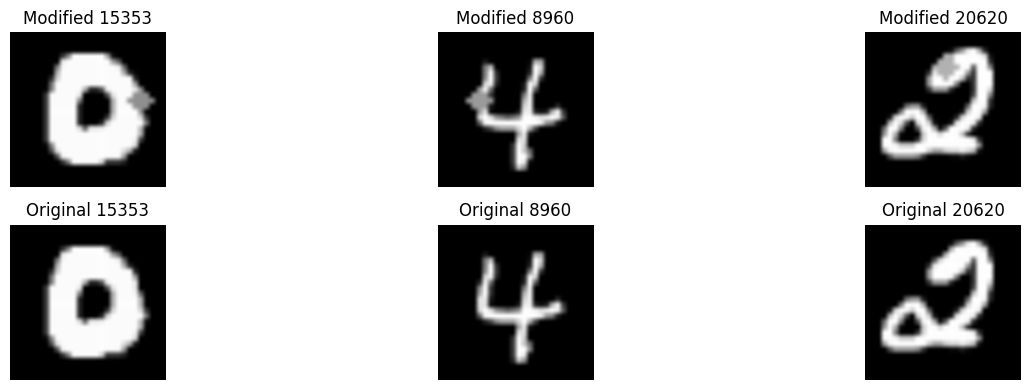

In [6]:
show_sample_images_pair(train_dataset, num_samples=3)
# Example usage:


In [7]:
def show_sample_images_2(dataset, num_samples=10, title='Modified Images'):
    plt.figure(figsize=(num_samples * 1.5, 2))
    indices = torch.randperm(len(dataset))[:num_samples]

    for i, idx in enumerate(indices):
        sample = dataset[idx]

        # Defensive unpacking
        img = sample[0]
        label = sample[1]
        image_orig = sample[2] if len(sample) > 2 else None
        dot_info = sample[3] if len(sample) > 3 else None
        sample_idx = sample[4] if len(sample) > 4 else None

        if isinstance(img, torch.Tensor):
            img = img.squeeze().numpy()

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img, cmap='gray')

        # Overlay the anomaly location (scaled)
        if dot_info is not None:
            scale = img.shape[0] / 28  # dynamic scale
            y = dot_info['y'] * scale
            x = dot_info['x'] * scale
            radius = dot_info['radius'] * scale / 2
            plt.scatter(x, y, s=(radius * 8)**2, edgecolor='red', facecolor='none', linewidths=1.5)

        plt.axis('off')
        plt.title(str(int(label)), fontsize=10)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

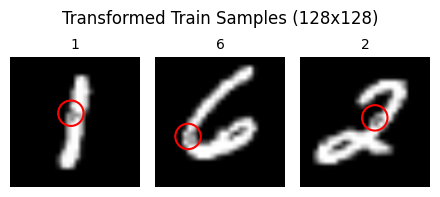

In [8]:
show_sample_images_2(train_dataset, num_samples=3, title="Transformed Train Samples (128x128)")

In [9]:
def random_mask_v5_opt1(
    x, 
    grey_dot_coords=None,
    mask_ratio=0.5,      
    patch_size=8, 
    block_size=3,      
    threshold=0.01, 
    dot_space='28',     # <---- new
    debug=False
):
    B, C, H, W = x.shape
    masks = torch.ones_like(x)
    n_h, n_w = H // patch_size, W // patch_size

    for b in range(B):
        # --- Use stored grey dot info if available ---
        if grey_dot_coords is not None and b < len(grey_dot_coords) and grey_dot_coords[b] is not None:
            info = grey_dot_coords[b]
            y_dot = info.get('y', None)
            x_dot = info.get('x', None)
            radius = info.get('radius', 2)

            # --- Convert to scalar if needed ---
            def to_scalar(val):
                if isinstance(val, (np.ndarray, torch.Tensor)):
                    return int(val.flatten()[0])
                else:
                    return int(val)
            y_dot = to_scalar(y_dot)
            x_dot = to_scalar(x_dot)
            radius = to_scalar(radius)
        else:
            # fallback: random patch
            y_dot = np.random.randint(H)
            x_dot = np.random.randint(W)
            radius = 2

        # --- Scale coordinates only if they’re from 28x28 space ---
        if dot_space == '28':
            scale = H / 28
            y_dot = int(y_dot * scale)
            x_dot = int(x_dot * scale)

        # --- Mask patch block around dot ---
        patch_y = y_dot // patch_size
        patch_x = x_dot // patch_size
        half_block = block_size // 2
        start_y = max(0, patch_y - half_block)
        end_y = min(n_h, patch_y + half_block + 1)
        start_x = max(0, patch_x - half_block)
        end_x = min(n_w, patch_x + half_block + 1)
        
        h_start, h_end = start_y * patch_size, end_y * patch_size
        w_start, w_end = start_x * patch_size, end_x * patch_size

        masks[b, :, h_start:h_end, w_start:w_end] = 0

        if debug:
            print(f"[Batch {b}] dot=({y_dot},{x_dot}), mask block y=({h_start}:{h_end}), x=({w_start}:{w_end})")

    return x * masks, masks


In [10]:
def show_sample_with_mask(dataset, mask_fn, num_samples=5, patch_size=16, title="Masked Images", debug=False):
    """
    Display images from the dataset with a mask applied around grey-dot anomalies.

    Args:
        dataset: InMemoryMNISTDataset instance
        mask_fn: function(x, grey_dot_coords, patch_size, debug) -> masked_x, mask
        num_samples: number of images to display
        patch_size: size of the square patch to mask
        title: figure title
        debug: if True, print debug info from mask_fn
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    plt.figure(figsize=(num_samples * 3, 3))

    indices = torch.randperm(len(dataset))[:num_samples]

    for i, idx in enumerate(indices):
        sample = dataset[idx]

        # --- Unpack sample ---
        img        = sample[0]
        label      = sample[1]
        dot_info   = sample[3] if len(sample) > 3 else None

        # --- Convert to tensor with batch dimension ---
        if isinstance(img, np.ndarray):
            img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0
        elif isinstance(img, torch.Tensor):
            img_tensor = img.unsqueeze(0) if img.ndim == 3 else img.unsqueeze(0).unsqueeze(0)
        img_tensor = img_tensor.to(device)

        # --- Prepare grey-dot dict for masking ---
        dot_dict = dot_info if isinstance(dot_info, dict) else None

        # --- Apply mask function ---
        masked_img, _ = mask_fn(
            img_tensor,
            grey_dot_coords=[dot_dict],
            patch_size=patch_size,
            debug=debug
        )

        # --- Convert to CPU numpy for plotting ---
        img_np = img_tensor[0, 0].cpu().numpy()
        masked_np = masked_img[0, 0].cpu().numpy()

        # --- Plot original image ---
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(img_np, cmap='gray')
        plt.title(f"Label: {label}")
        plt.axis('off')

        # --- Plot masked image ---
        plt.subplot(2, num_samples, i + 1 + num_samples)
        plt.imshow(masked_np, cmap='gray')
        plt.axis('off')

        # --- Overlay smaller red circle ---
        if dot_dict is not None:
            scale = img_np.shape[0] / 28
            y = dot_dict['y'] * scale
            x = dot_dict['x'] * scale
            radius = 1.5  # smaller radius for visualization

            plt.subplot(2, num_samples, i + 1)
            plt.scatter(x, y, s=(radius*8)**2, edgecolor='red', facecolor='none', linewidths=1.2)
            plt.subplot(2, num_samples, i + 1 + num_samples)
            plt.scatter(x, y, s=(radius*8)**2, edgecolor='red', facecolor='none', linewidths=1.2)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


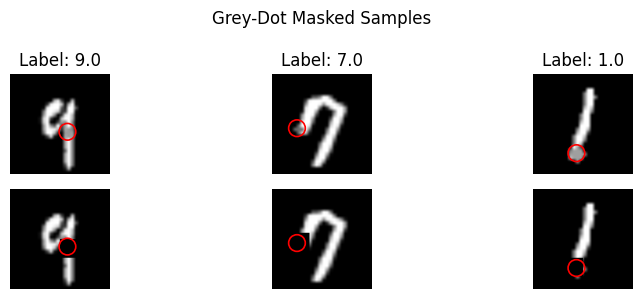

In [11]:
show_sample_with_mask(train_dataset, random_mask_v5_opt1, num_samples=3, patch_size=8, title="Grey-Dot Masked Samples")

In [12]:
# -----------------------------------------------------
# Expanded-Channel VAE (more expressive)
# -----------------------------------------------------
class Encoder(nn.Module):
    def __init__(self, latent_dim=128):  # larger latent for expressiveness
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 64, 4, stride=2, padding=1),   # 128->64
            nn.LeakyReLU(0.1),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # 64->32
            nn.LeakyReLU(0.1),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),# 32->16
            nn.LeakyReLU(0.1),
            nn.Flatten()
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 128, 128)
            flat_dim = self.conv(dummy).shape[1]
        self.flat_dim = flat_dim
        self.fc_mu = nn.Linear(flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, latent_dim)

    def forward(self, x):
        h = self.conv(x)
        return self.fc_mu(h), self.fc_logvar(h)


class Decoder(nn.Module):
    def __init__(self, latent_dim=128, flat_dim=None):
        super().__init__()
        self.fc = nn.Linear(latent_dim, flat_dim)
        self.up = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1), # 16->32
            nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # 32->64
            nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(64, 1, 4, stride=2, padding=1),    # 64->128
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.fc(z)
        B = x.size(0)
        spatial = 16  # matches encoder output spatial
        x = x.view(B, 256, spatial, spatial)
        return self.up(x)


class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim, flat_dim=self.encoder.flat_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar


In [13]:
# -----------------------------------------------------
# Loss (reconstruction on masked region + KL)
# -----------------------------------------------------
def vae_masked_loss(x_rec, x_orig, mask, mu, logvar, recon_fn=nn.MSELoss(reduction='mean'), beta=1.0):
    region = (1 - mask).expand_as(x_orig)
    recon = recon_fn(x_rec * region, x_orig * region)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / mu.size(0)
    return recon + beta * kl, recon, kl

def kl_anneal(epoch, max_epochs, max_beta=1.0):
    return min(1.0, epoch / (0.5 * max_epochs)) * max_beta

In [14]:
# -------------------------------------------------
# Training + Evaluation Function (VAE version)
# -------------------------------------------------
def train_and_evaluate(
    model, train_loader, val_loader,
    n_epochs=10, mask_ratio=0.3, lr=1e-3,
    patience=10, mask_fn=None, patch_size=None,
    block_size=None,
    show_batch_progress=True,
    beta=1.0  # KL weight
):
    """
    Train a VAE model with mask-weighted reconstruction loss + KL divergence.
    Handles grey_dot_coords safely for all batches.
    """
    if mask_fn is None:
        raise ValueError("You must provide a masking function (mask_fn).")

    device = next(model.parameters()).device
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        # -------------------
        # Training
        # -------------------
        model.train()
        total_train_loss = 0
        epoch_start = time.time()

        train_iter = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs} - Training", leave=False) \
                     if show_batch_progress else train_loader

        for batch in train_iter:
            # --- Extract grey_dot_coords ---
            if len(batch) == 3:
                x, _ = batch
                grey_dot_coords = [None] * x.size(0)
            else:
                x, _, dot_info = batch[:3]
                B = x.size(0)
                if isinstance(dot_info, dict):
                    grey_dot_coords = [dot_info] + [None]*(B-1)
                elif isinstance(dot_info, (list, tuple)):
                    grey_dot_coords = [di if isinstance(di, dict) else None for di in dot_info]
                    if len(grey_dot_coords) < B:
                        grey_dot_coords += [None]*(B - len(grey_dot_coords))
                else:
                    grey_dot_coords = [None]*B

            x = x.to(device)
            x_masked, mask = mask_fn(
                x, 
                grey_dot_coords=grey_dot_coords,
                mask_ratio=mask_ratio, 
                patch_size=patch_size,
                block_size=block_size
            )

            # Forward pass
            x_rec, mu, logvar = model(x_masked)
            loss, recon_loss, kl_loss = vae_masked_loss(
                x_rec, x, mask, mu, logvar, beta=beta
            )

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_train_loss += loss.item() * x.size(0)
            if show_batch_progress:
                train_iter.set_postfix({"batch_loss": f"{loss.item():.6f}"})

        avg_train_loss = total_train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)

        # -------------------
        # Validation
        # -------------------
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                if len(batch) == 3:
                    x, _ = batch
                    grey_dot_coords = [None] * x.size(0)
                else:
                    x, _, dot_info = batch[:3]
                    B = x.size(0)
                    if isinstance(dot_info, dict):
                        grey_dot_coords = [dot_info] + [None]*(B-1)
                    elif isinstance(dot_info, (list, tuple)):
                        grey_dot_coords = [di if isinstance(di, dict) else None for di in dot_info]
                        if len(grey_dot_coords) < B:
                            grey_dot_coords += [None]*(B - len(grey_dot_coords))
                    else:
                        grey_dot_coords = [None]*B

                x = x.to(device)
                x_masked, mask = mask_fn(
                    x, 
                    grey_dot_coords=grey_dot_coords,
                    mask_ratio=mask_ratio, 
                    patch_size=patch_size,
                    block_size=block_size
                )

                x_rec, mu, logvar = model(x_masked)
                loss, _, _ = vae_masked_loss(x_rec, x, mask, mu, logvar, beta=beta)
                total_val_loss += loss.item() * x.size(0)

        avg_val_loss = total_val_loss / len(val_loader.dataset)
        val_losses.append(avg_val_loss)

        epoch_time = time.time() - epoch_start
        """print(f"Epoch {epoch+1}/{n_epochs} | "
              f"Train Loss: {avg_train_loss:.6f} | "
              f"Val Loss: {avg_val_loss:.6f} | "
              f"Time: {epoch_time:.1f}s")
        """
        # -------------------
        # Early Stopping
        # -------------------
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    return best_val_loss, train_losses, val_losses


=== Training | mask_fn=random_mask_v5_opt1, epochs=30, mask=0.2, lr=0.0001, patch_size=4, block_size=3 ===


Epoch 1/30 - Training:   0%|          | 0/268 [00:00<?, ?it/s]

Epoch 2/30 - Training:   0%|          | 0/268 [00:00<?, ?it/s]

Epoch 3/30 - Training:   0%|          | 0/268 [00:00<?, ?it/s]

Epoch 4/30 - Training:   0%|          | 0/268 [00:00<?, ?it/s]

...

Epoch 15/30 - Training:   0%|          | 0/268 [00:00<?, ?it/s]

Epoch 16/30 - Training:   0%|          | 0/268 [00:00<?, ?it/s]

Epoch 17/30 - Training:   0%|          | 0/268 [00:00<?, ?it/s]

Epoch 18/30 - Training:   0%|          | 0/268 [00:00<?, ?it/s]

Early stopping at epoch 18
Time for this run: 630.27 seconds
Test MSE: 0.036963


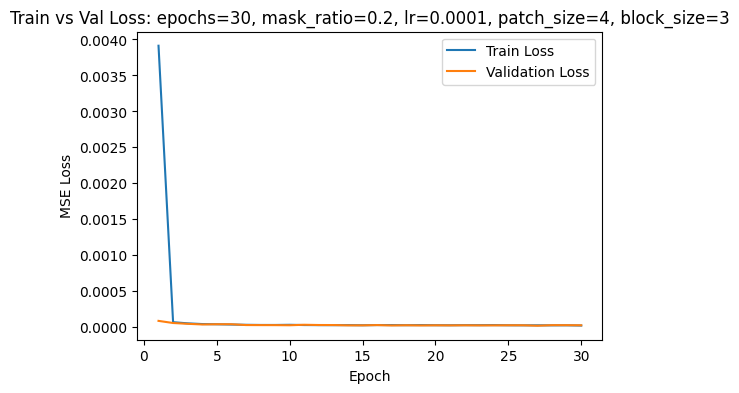

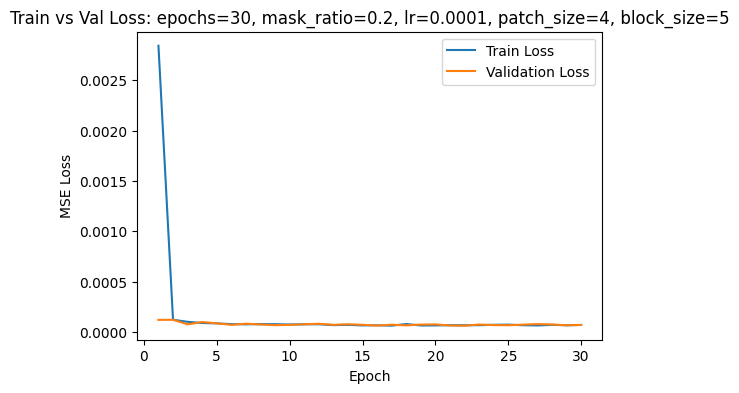

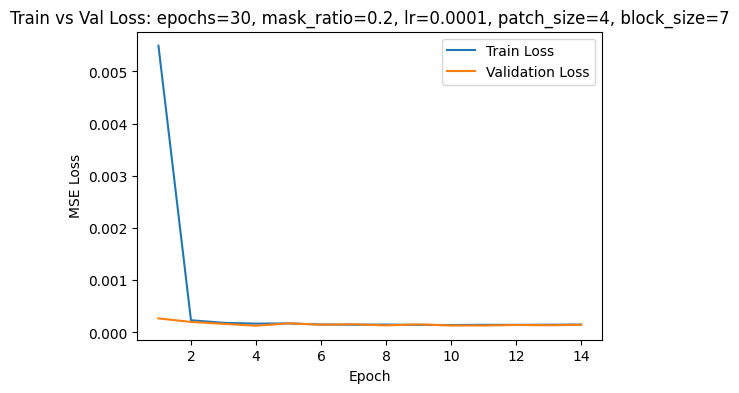

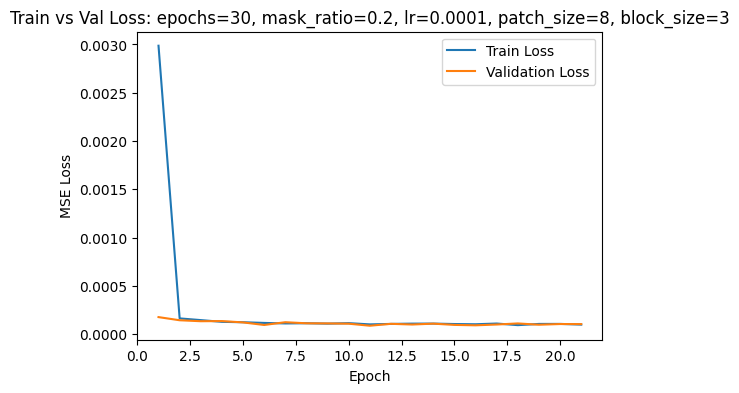

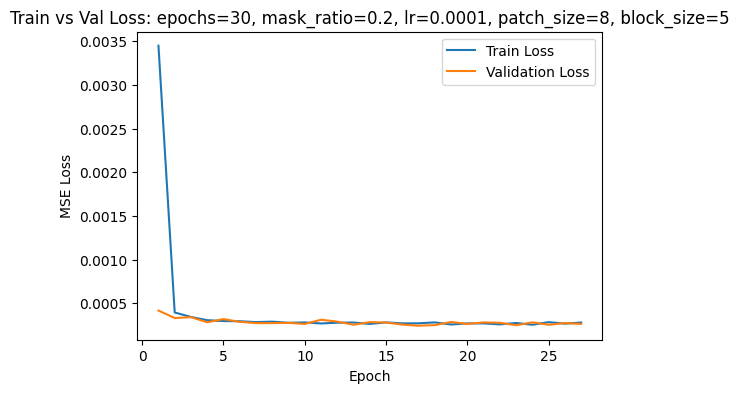

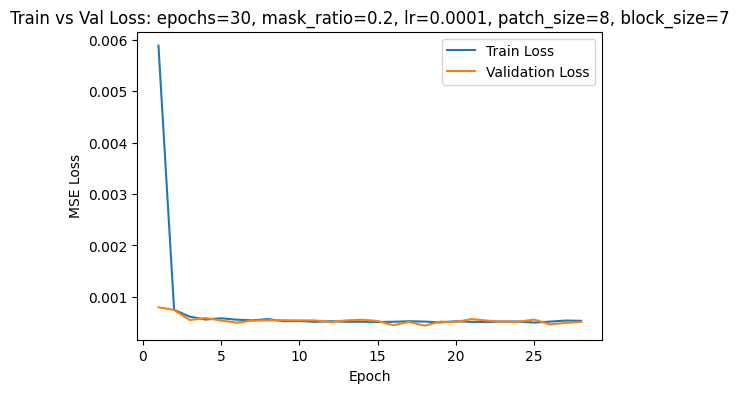

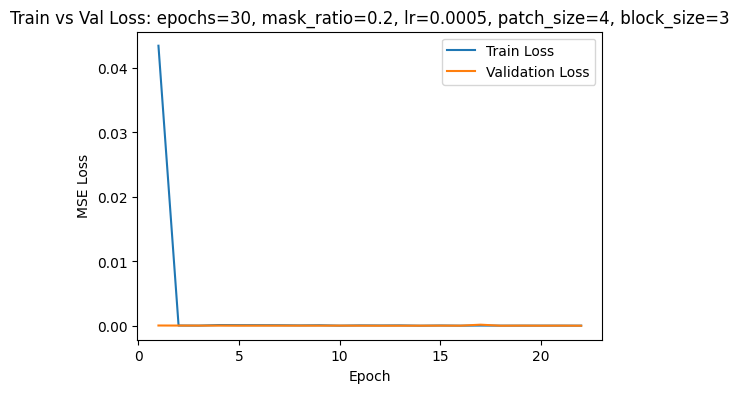

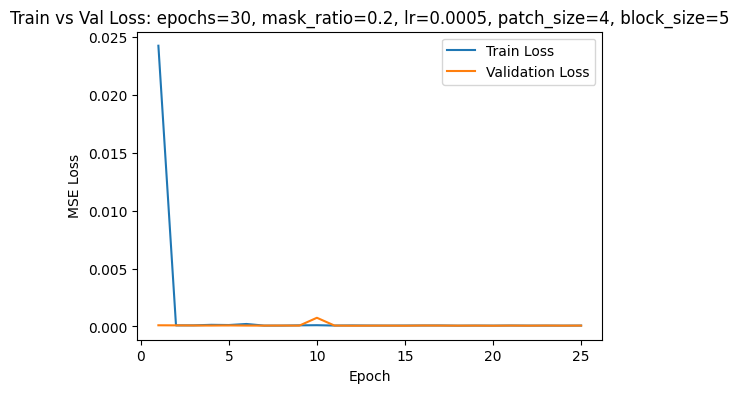

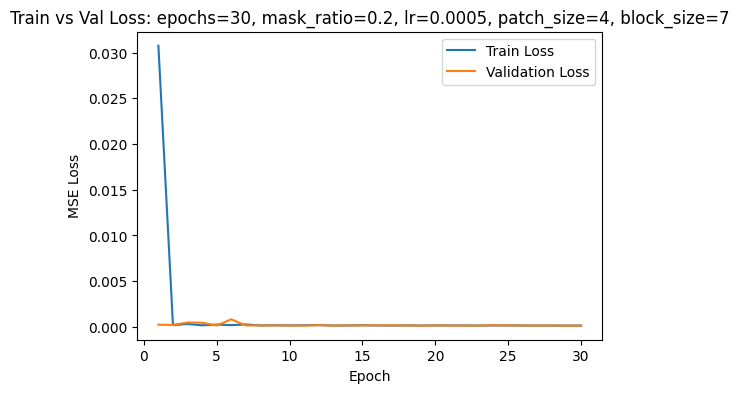

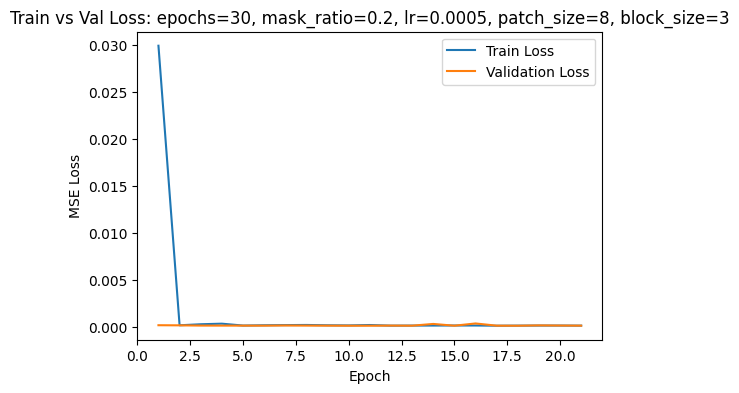

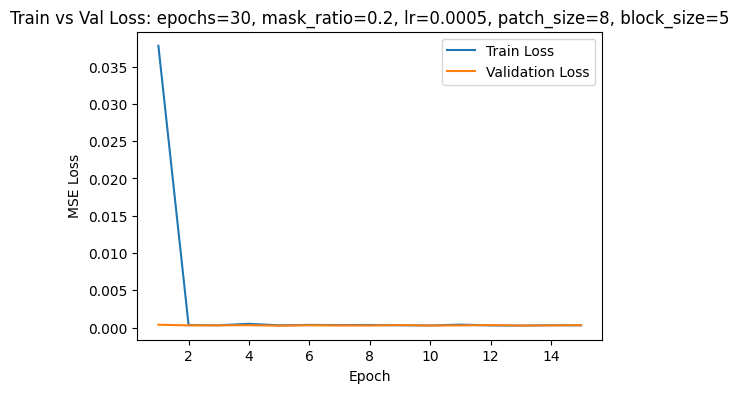

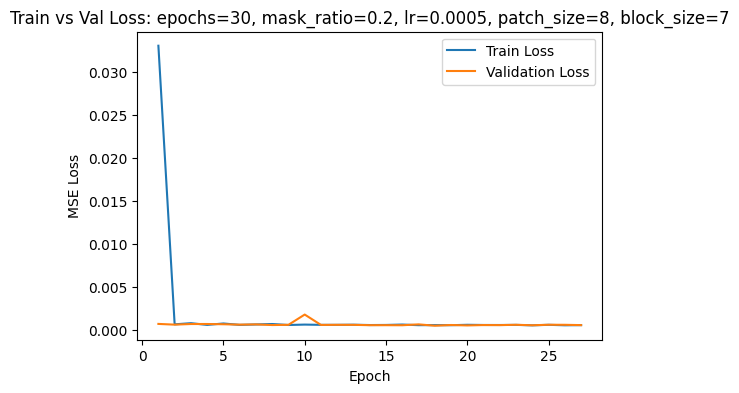

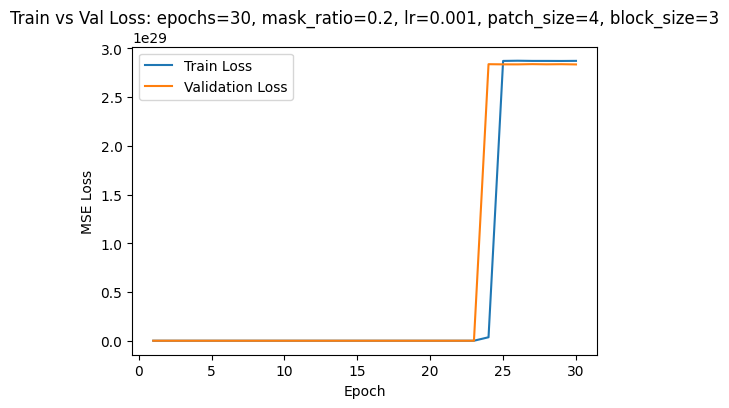

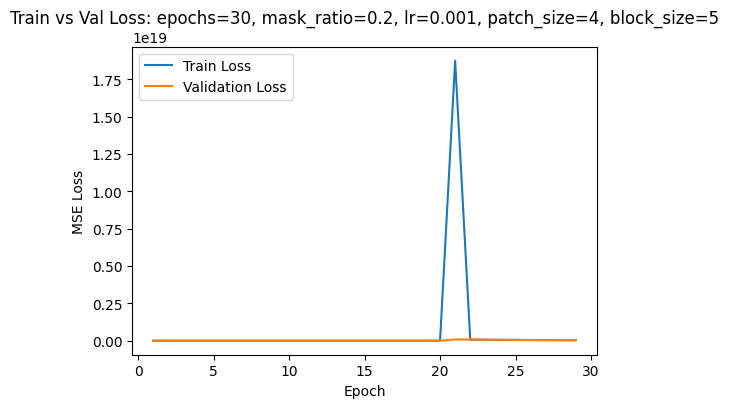

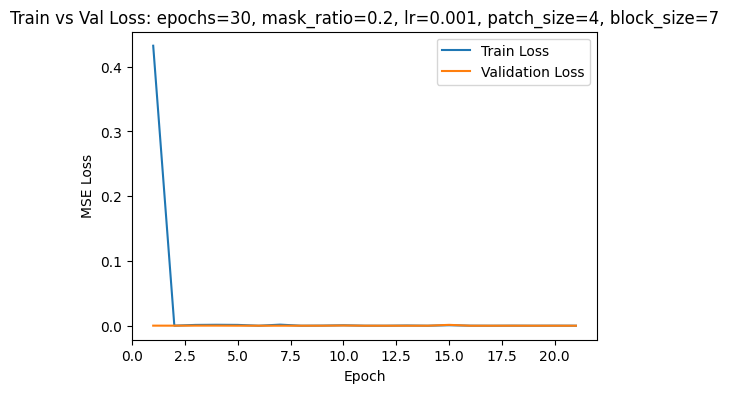

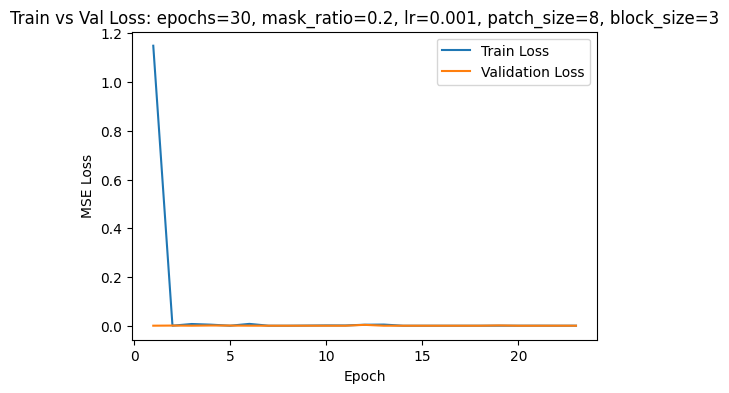

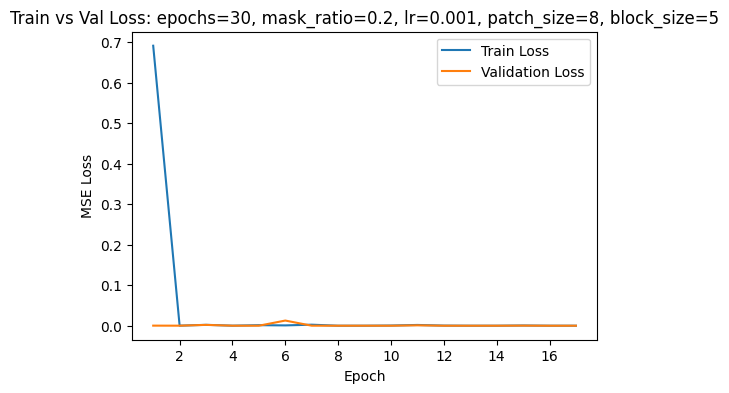

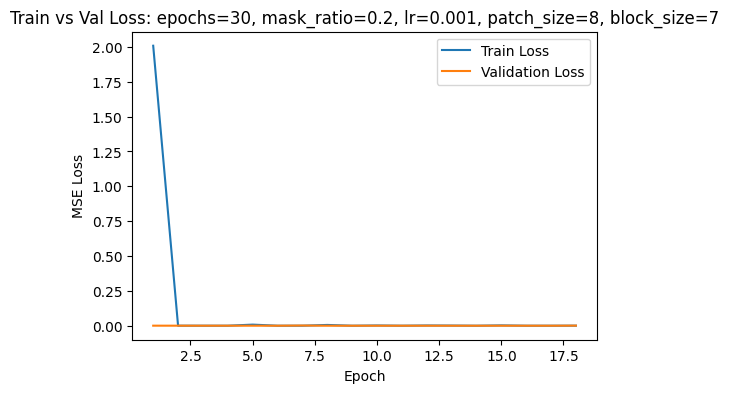

In [15]:
# -------------------------------------------------
# Hyperparameter sweep (VAE version)
# -------------------------------------------------
epoch_options      = [30]                # Number of training epochs
mask_options       = [0.2]               # Masking ratio
lr_options         = [1e-4, 5e-4, 1e-3] # Learning rates used
patch_size_options = [4, 8]              # Size of mask patches (pixels)
block_size_options = [3, 5, 7]           # Block sizes for block-style masking (pixels)
mask_fn_options = [
    ("random_mask_v5_opt1", random_mask_v5_opt1),
]

results = []
train_val_curves = {}
test_results = []

def extract_batch_with_orig(batch):
    """
    Return x, x_orig, grey_dot_coords robustly for arbitrary batch structure.
    """
    if len(batch) == 2:
        x, _ = batch
        x_orig = None
        grey_dot_coords = [None]*x.size(0)
    else:
        x = batch[0]
        x_orig, dot_info = None, None
        if len(batch) >= 3:
            third = batch[2]
            if isinstance(third, (torch.Tensor, np.ndarray, Image.Image)):
                x_orig = third
            else:
                dot_info = third
        if len(batch) >= 4:
            fourth = batch[3]
            if x_orig is None and isinstance(fourth, (torch.Tensor, np.ndarray, Image.Image)):
                x_orig = fourth
            elif dot_info is None and (isinstance(fourth, dict) or isinstance(fourth, (list, tuple))):
                dot_info = fourth

        B = x.size(0)
        if dot_info is None:
            grey_dot_coords = [None]*B
        elif isinstance(dot_info, dict) and all(isinstance(dot_info.get(k), torch.Tensor) for k in ("y","x")):
            n = dot_info["y"].numel()
            grey_dot_coords = [
                {"y": int(dot_info["y"][i].item()),
                 "x": int(dot_info["x"][i].item()),
                 "radius": int(dot_info.get("radius", torch.tensor(1))[i].item()) if "radius" in dot_info else 1}
                for i in range(n)
            ]
            if len(grey_dot_coords) < B:
                grey_dot_coords += [None]*(B-B)
        elif isinstance(dot_info, (list, tuple)):
            grey_dot_coords = [di if isinstance(di, dict) else None for di in dot_info]
            if len(grey_dot_coords) < B:
                grey_dot_coords += [None]*(B-len(grey_dot_coords))
        else:
            grey_dot_coords = [dot_info]+[None]*(B-1) if isinstance(dot_info, dict) else [None]*B

        if x_orig is not None and isinstance(x_orig, torch.Tensor) and x_orig.shape[0] != x.shape[0]:
            try:
                x_orig = x_orig.repeat(x.shape[0], *([1]*(x_orig.dim()-1)))
            except:
                x_orig = None

    return x, x_orig, grey_dot_coords

# ======================================================
# Main sweep loop (training + test + visualization)
# ======================================================
for mask_fn_name, mask_fn in mask_fn_options:
    for n_epoch in epoch_options:
        for mask_ratio in mask_options:
            for lr in lr_options:
                for patch_size in patch_size_options:
                    for block_size in block_size_options:
                        print("\n" + "="*60)
                        print(f"=== Training | mask_fn={mask_fn_name}, epochs={n_epoch}, "
                              f"mask={mask_ratio}, lr={lr}, patch_size={patch_size}, block_size={block_size} ===")

                        start_time = time.time()
                        model_copy = VAE(latent_dim=128).to(device)

                        # Train & evaluate
                        best_val_loss, train_losses, val_losses = train_and_evaluate(
                            model_copy, train_loader, val_loader,
                            n_epochs=n_epoch,
                            mask_ratio=mask_ratio,
                            lr=lr,
                            patience=10,
                            mask_fn=mask_fn,
                            patch_size=patch_size,
                            block_size=block_size,
                            beta=1.0
                        )

                        elapsed = time.time() - start_time
                        print(f"Time for this run: {elapsed:.2f} seconds")

                        # -------------------
                        # Test evaluation
                        # -------------------
                        model_copy.eval()
                        mse_loss = nn.MSELoss()
                        test_mse = 0.0
                        with torch.no_grad():
                            for batch in test_loader:
                                x, x_orig, grey_dot_coords = extract_batch_with_orig(batch)
                                x = x.to(device)
                                x_masked, mask = mask_fn(
                                    x, grey_dot_coords=grey_dot_coords,
                                    mask_ratio=mask_ratio, patch_size=patch_size,
                                    block_size=block_size
                                )
                                x_rec, _, _ = model_copy(x_masked)
                                loss = mse_loss(x_rec*mask, x*mask)
                                test_mse += loss.item()*x.size(0)
                        test_mse /= len(test_loader.dataset)
                        print(f"Test MSE: {test_mse:.6f}")

                        # -------------------
                        # Store results
                        # -------------------
                        results.append({
                            "mask_fn": mask_fn_name,
                            "n_epochs": n_epoch,
                            "mask_ratio": mask_ratio,
                            "lr": lr,
                            "patch_size": patch_size,
                            "block_size": block_size,
                            "val_loss": best_val_loss,
                            "test_mse": test_mse,
                            "train_time_s": elapsed
                        })
                        train_val_curves[(n_epoch, mask_ratio, lr, patch_size, block_size)] = (train_losses, val_losses)

                        # -------------------
                        # Visual comparison
                        # -------------------
                        """
                        with torch.no_grad():
                            batch = next(iter(test_loader))
                            x, x_orig, grey_dot_coords = extract_batch_with_orig(batch)
                            x = x.to(device)
                            x_orig_t = x_orig.to(device) if x_orig is not None else None

                            x_masked, mask = mask_fn(
                                x,
                                grey_dot_coords=grey_dot_coords,
                                mask_ratio=mask_ratio,
                                patch_size=patch_size,
                                block_size=block_size
                            )
                            x_rec, _, _ = model_copy(x_masked)

                        n_show = 3
                        plt.figure(figsize=(12,8))  # 4 rows x n_show columns

                        for i in range(n_show):
                            orig_np = x_orig_t[i,0].cpu().numpy() if x_orig_t is not None else x[i,0].cpu().numpy()
                            img_with_dot_np = x[i,0].cpu().numpy()
                            masked_np = x_masked[i,0].cpu().numpy()
                            rec_np = x_rec[i,0].cpu().numpy()
                            mask_np = (mask[i,0].cpu().numpy() > 0.5).astype(np.float32)
                            filled = masked_np*mask_np + rec_np*(1-mask_np)

                            # 1️⃣ Original
                            plt.subplot(4,n_show,i+1)
                            plt.imshow(orig_np, cmap='gray', vmin=0, vmax=1)
                            plt.title("Original (no dot)")
                            plt.axis("off")

                            # 2️⃣ Image with grey dot
                            plt.subplot(4,n_show,i+1+n_show)
                            plt.imshow(img_with_dot_np, cmap='gray', vmin=0, vmax=1)
                            plt.title("Image (with grey dot)")
                            plt.axis("off")

                            # Overlay dot marker
                            if grey_dot_coords is not None and i < len(grey_dot_coords) and grey_dot_coords[i] is not None:
                                info = grey_dot_coords[i]
                                if info.get('y') is not None and info.get('x') is not None:
                                    H = img_with_dot_np.shape[0]
                                    scale = H / 28.0
                                    y = int(info['y']*scale)
                                    x_ = int(info['x']*scale)
                                    plt.scatter(x_, y, s=80, edgecolors='red', facecolors='none', linewidths=1.2)

                            # 3️⃣ Masked input
                            plt.subplot(4,n_show,i+1+2*n_show)
                            plt.imshow(masked_np, cmap='gray', vmin=0, vmax=1)
                            plt.title("Masked Input (with dot)")
                            plt.axis("off")

                            # 4️⃣ Reconstructed (filled)
                            plt.subplot(4,n_show,i+1+3*n_show)
                            plt.imshow(filled, cmap='gray', vmin=0, vmax=1)
                            plt.title("Reconstructed (filled)")
                            plt.axis("off")

                        plt.tight_layout()
                        plt.show()
                        """

# ======================================================
# Plot train vs val loss
# ======================================================
df_val = pd.DataFrame(results)

for key, (train_losses, val_losses) in train_val_curves.items():
    n_epoch, mask_ratio, lr, patch_size, block_size = key
    plt.figure(figsize=(6,4))
    plt.plot(range(1,len(train_losses)+1), train_losses, label="Train Loss")
    plt.plot(range(1,len(val_losses)+1), val_losses, label="Validation Loss")
    plt.title(f"Train vs Val Loss: epochs={n_epoch}, mask_ratio={mask_ratio}, lr={lr}, patch_size={patch_size}, block_size={block_size}")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.show()
